In [1]:
from google.colab import drive
import os, shutil

# Try to unmount in case it's half-mounted
try:
    drive.flush_and_unmount()
except Exception as e:
    print("Unmount info:", e)

# Ensure clean local mountpoint
if os.path.exists("/content/drive"):
    try:
        # Only remove if it's NOT a mount
        if not os.path.ismount("/content/drive"):
            shutil.rmtree("/content/drive")
    except Exception as e:
        print("Cleanup info:", e)
os.makedirs("/content/drive", exist_ok=True)

# Mount fresh
drive.mount("/content/drive", force_remount=True)

# Then set ROOT
ROOT = "/content/drive/MyDrive/Dissertation/Dataset"

%pip -q install tsfel mne numpy pandas

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00


In [2]:
import tsfel, mne, numpy as np
from pathlib import Path

# --- Paths ---
ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
INTERIM = f"{ROOT}/data/interim"
FEATURES = f"{ROOT}/data/features"
Path(FEATURES).mkdir(parents=True, exist_ok=True)

subj = "s32"  # <-- change per subject
epo60_path = Path(INTERIM) / f"{subj}-epo60.fif"   # 60 s epochs at 256 Hz

# --- Load 60 s epochs ---
epochs60 = mne.read_epochs(str(epo60_path), preload=True, verbose=False)

# >>> CRITICAL FIX: keep only the 32 standard DEAP EEG channels <<<
EEG_CHS = [
    "Fp1","AF3","F3","F7","FC5","FC1","C3","T7","CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
    "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz","C4","T8","CP6","CP2","P4","P8","PO4","O2",
]
epochs60.pick_channels(EEG_CHS)   # drop Status, -1, any junk

X_eeg = epochs60.get_data()             # (40, 32, n_times)
sf = float(epochs60.info["sfreq"])      # 256.0
ch_names = np.array(epochs60.ch_names)
print("EEG:", X_eeg.shape, "sf:", sf)
print("Channels:", ch_names, "len:", len(ch_names))

# --- EXACT 7 features we want (names are human-readable; we match robustly) ---
FEATURES_7 = [
    ("spectral",    "Spectral entropy"),      # F1
    ("spectral",    "Spectral centroid"),     # F2
    ("spectral",    "Spectral spread"),       # F3
    ("spectral",    "Median frequency"),      # F4
    ("spectral",    "Power bandwidth"),       # F5
    ("spectral",    "Max power spectrum"),    # F6  (or "Maximum power spectrum")
    ("statistical", "Average power"),         # F7
]
feat_names = np.array([n for _, n in FEATURES_7])

def _norm(s: str) -> str:
    # normalize strings for safe, case/space-insensitive matching
    return "".join(s.lower().replace("-", " ").split())

# --- Build TSFEL config: turn OFF everything, enable only our 7 (by robust name match) ---
cfg = tsfel.get_features_by_domain("all")   # nested dict: {temporal:{...}, statistical:{...}, spectral:{...}}
# disable all
for dom in cfg:
    for k in cfg[dom]:
        cfg[dom][k]["use"] = "no"

# enable only requested features (robust key match per domain)
for dom_wanted, name_wanted in FEATURES_7:
    dom_dict = cfg.get(dom_wanted, {})
    keys_norm = {_norm(k): k for k in dom_dict.keys()}
    wanted_key = _norm(name_wanted)
    if wanted_key not in keys_norm and name_wanted == "Max power spectrum":
        for alias in ("Maximum power spectrum",):
            if _norm(alias) in keys_norm:
                wanted_key = _norm(alias)
                break
    if wanted_key not in keys_norm:
        raise KeyError(f"TSFEL feature not found in domain '{dom_wanted}': '{name_wanted}'")
    real_key = keys_norm[wanted_key]
    dom_dict[real_key]["use"] = "yes"

# constrain spectral features to 1–40 Hz (where parameters exist)
for k, v in cfg.get("spectral", {}).items():
    params = v.get("parameters", {})
    for lo in ("low_freq","low_frequency","min_freq"):
        if lo in params: params[lo] = 1
    for hi in ("high_freq","high_frequency","max_freq"):
        if hi in params: params[hi] = 40

# --- Per-epoch × channel → 7-dim vector in fixed order ---
import re

def _norm(s: str) -> str:
    return "".join(s.lower().replace("-", " ").split())

def _strip_win_prefix(col: str) -> str:
    # remove leading window index like "0_" or "1_"
    return re.sub(r"^\d+_", "", col)

def tsfel_vec_7(x1d: np.ndarray) -> np.ndarray:
    df = tsfel.time_series_features_extractor(cfg, x1d, fs=sf, verbose=0)
    cols = list(df.columns)
    name_map = {}
    for c in cols:
        key = _norm(_strip_win_prefix(c))
        name_map[key] = c

    out = []
    for _, wanted in FEATURES_7:
        key = _norm(wanted)
        if key not in name_map and wanted == "Max power spectrum":
            key_alt = _norm("Maximum power spectrum")
            if key_alt in name_map:
                key = key_alt
        if key not in name_map:
            raise KeyError(f"Feature column not found: '{wanted}'. Available (first 10): {cols[:10]}")
        out.append(float(df.iloc[0][name_map[key]]))
    return np.asarray(out, dtype=np.float32)

# --- Extract features: X -> (videos, channels, features=7) ---
n_ep, n_ch, _ = X_eeg.shape
X = np.zeros((n_ep, n_ch, 7), dtype=np.float32)
for ei in range(n_ep):
    for ci in range(n_ch):
        X[ei, ci, :] = tsfel_vec_7(X_eeg[ei, ci, :])

print("Final tensor X shape:", X.shape)  # expect (40, 32, 7)


/tmp/ipython-input-1013870787.py:14: RuntimeWarning: This filename (/content/drive/MyDrive/Dissertation/Dataset/data/interim/s32-epo60.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs60 = mne.read_epochs(str(epo60_path), preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
EEG: (40, 32, 15361) sf: 256.0
Channels: ['Fp1' 'AF3' 'F3' 'F7' 'FC5' 'FC1' 'C3' 'T7' 'CP5' 'CP1' 'P3' 'P7' 'PO3'
 'O1' 'Oz' 'Pz' 'Fp2' 'AF4' 'Fz' 'F4' 'F8' 'FC6' 'FC2' 'Cz' 'C4' 'T8'
 'CP6' 'CP2' 'P4' 'P8' 'PO4' 'O2'] len: 32
Final tensor X shape: (40, 32, 7)


In [3]:
# --- Save NumPy only (no labels yet) ---
out_npz = Path(FEATURES)/f"{subj}_X7_60s_256Hz.npz"
np.savez_compressed(out_npz, X=X, subject=subj, channels=ch_names, features=feat_names)
print("Saved:", out_npz)

Saved: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz.npz


In [4]:
import numpy as np
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
feat_path = Path(FEATURES)/f"{subj}_X7_60s_256Hz.npz"

data = np.load(feat_path, allow_pickle=True)
print("Keys:", list(data.keys()))
X        = data["X"]          # (40, 32, 7)
subject  = data["subject"].item() if data["subject"].dtype==object else data["subject"]
channels = data["channels"]   # (32,)
features = data["features"]   # (7,)

print("X shape:", X.shape)
print("subject:", subject)
print("channels[0:5]:", channels[:5])
print("features:", features)


Keys: ['X', 'subject', 'channels', 'features']
X shape: (40, 32, 7)
subject: s32
channels[0:5]: ['Fp1' 'AF3' 'F3' 'F7' 'FC5']
features: ['Spectral entropy' 'Spectral centroid' 'Spectral spread'
 'Median frequency' 'Power bandwidth' 'Max power spectrum' 'Average power']


In [5]:
# one video, one channel, all 7 features
v, c = 0, 0
print("Sample row (video 0, channel 0):", X[v, c, :])

# basic stats
print("Min/Max overall:", X.min(), X.max())
print("Per-feature mean (first 3 features):", X.reshape(-1, X.shape[-1])[:, :3].mean(axis=0))


Sample row (video 0, channel 0): [7.3113304e-01 1.5762147e+01 1.3914808e+01 1.2032550e+01 3.1247965e+01
 9.1858864e-01 1.0818810e-08]
Min/Max overall: 1.2460922e-09 42.597225
Per-feature mean (first 3 features): [ 0.74307823 15.629671   13.642487  ]


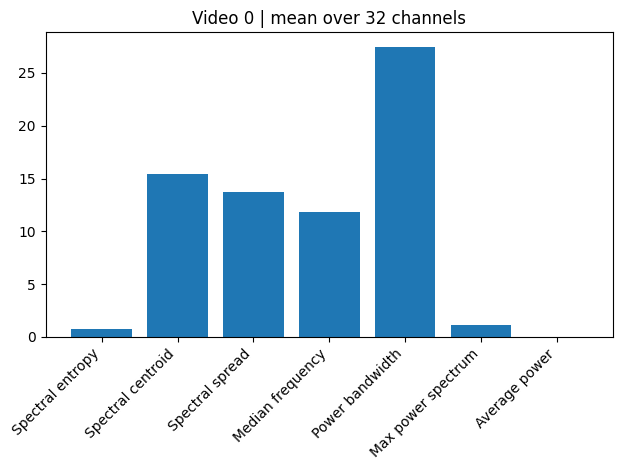

In [6]:
import matplotlib.pyplot as plt

v = 0  # video index
mean_over_ch = X[v].mean(axis=0)  # (7,)
plt.bar(range(7), mean_over_ch)
plt.xticks(range(7), features, rotation=45, ha='right')
plt.title(f"Video {v} | mean over 32 channels")
plt.tight_layout(); plt.show()


In [7]:
import numpy as np
np.set_printoptions(suppress=True, precision=4, linewidth=140)

# whole 7-feature row for one video+channel
v, c = 0, 0
print("X[v,c,:] =", X[v, c, :])

# first 3 videos, first 2 channels, all 7 features
print(X[0:3, 0:2, :])


X[v,c,:] = [ 0.7311 15.7621 13.9148 12.0325 31.248   0.9186  0.    ]
[[[ 0.7311 15.7621 13.9148 12.0325 31.248   0.9186  0.    ]
  [ 0.7036 14.65   13.3662 10.416  26.6316  1.4087  0.    ]]

 [[ 0.7085 14.9322 14.4885 10.6826 24.7484  1.6001  0.    ]
  [ 0.7124 14.3171 14.3299 10.2827 21.6486  1.289   0.    ]]

 [[ 0.7221 14.7398 14.349  10.516  25.6817  0.89    0.    ]
  [ 0.7038 13.8234 13.5928  9.866  21.9986  1.031   0.    ]]]


In [8]:
import numpy as np, pandas as pd
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
npz = np.load(Path(FEATURES)/f"{subj}_X7_60s_256Hz.npz", allow_pickle=True)

X        = npz["X"]            # (40,32,7)
channels = npz["channels"]     # (32,)
features = npz["features"]     # (7,)

V, C, F = X.shape  # 40,32,7

# Long-form table: Video, Channel, Feature, Value
df = pd.DataFrame({
    "Video":   np.repeat(np.arange(V), C*F),
    "Channel": np.tile(np.repeat(channels, F), V),
    "Feature": np.tile(features, V*C),
    "Value":   X.ravel()
})

# Peek
print(df.shape)
df.head(12)


(8960, 4)


,Video,Channel,Feature,Value
0,0,Fp1,Spectral entropy,7.311330e-01
1,0,Fp1,Spectral centroid,1.576215e+01
2,0,Fp1,Spectral spread,1.391481e+01
3,0,Fp1,Median frequency,1.203255e+01
4,0,Fp1,Power bandwidth,3.124796e+01
5,0,Fp1,Max power spectrum,9.185886e-01
6,0,Fp1,Average power,1.081881e-08
7,0,AF3,Spectral entropy,7.035779e-01
8,0,AF3,Spectral centroid,1.464998e+01
9,0,AF3,Spectral spread,1.336624e+01


In [9]:
#Filtering

# all features for Video 0, Channel 'Cz'
df[(df["Video"]==0) & (df["Channel"]=="Cz")]

# all channels for Video 3, Feature 'Spectral entropy'
df[(df["Video"]==3) & (df["Feature"]=="Spectral entropy")]

# a single scalar: Video 5, Channel 'Fz', Feature 'Median frequency'
df.loc[(df["Video"]==5) & (df["Channel"]=="Fz") & (df["Feature"]=="Median frequency"), "Value"].item()


10.515981674194336

In [10]:
#Print Everything but use slicing
with pd.option_context("display.max_rows", None):
    display(df[:20])


,Video,Channel,Feature,Value
0,0,Fp1,Spectral entropy,7.311330e-01
1,0,Fp1,Spectral centroid,1.576215e+01
2,0,Fp1,Spectral spread,1.391481e+01
3,0,Fp1,Median frequency,1.203255e+01
4,0,Fp1,Power bandwidth,3.124796e+01
5,0,Fp1,Max power spectrum,9.185886e-01
6,0,Fp1,Average power,1.081881e-08
7,0,AF3,Spectral entropy,7.035779e-01
8,0,AF3,Spectral centroid,1.464998e+01
9,0,AF3,Spectral spread,1.336624e+01


In [11]:
##Labelling

In [12]:
# === Paths and params ===
from pathlib import Path
import numpy as np
import pandas as pd
import mne

ROOT      = "/content/drive/MyDrive/Dissertation/Dataset"   # make sure this matches Cell 1
INTERIM   = Path(ROOT) / "data" / "interim"
FEATURES  = Path(ROOT) / "data" / "features"
RATINGS   = Path(ROOT) / "subjective-ratings" / "participant_ratings.csv"

subj     = "s32"    # Change user accordingly
thr_avg  = 5.5      # threshold on average(Valence, Arousal)

# === Load features (prefer the base features file) ===
base_npz  = FEATURES / f"{subj}_X7_60s_256Hz.npz"
final_npz = FEATURES / f"{subj}_X7_60s_256Hz_final.npz"

if base_npz.exists():
    d = np.load(base_npz, allow_pickle=True)
elif final_npz.exists():
    d = np.load(final_npz, allow_pickle=True)
else:
    raise FileNotFoundError("No features NPZ found for subject", subj)

X = d["X"]  # (40, 32, 7)

# Channels and feature names: from NPZ or recover
if "channels" in d.files:
    channels = d["channels"]
else:
    ep_path = INTERIM / f"{subj}-epo60.fif"
    assert ep_path.exists(), f"Missing epochs to recover channels: {ep_path}"
    epochs = mne.read_epochs(str(ep_path), preload=False, verbose=False)
    channels = np.array(epochs.ch_names)

if "features" in d.files:
    featnames = d["features"]
else:
    featnames = np.array([
        "Spectral entropy", "Spectral centroid", "Spectral spread",
        "Median frequency", "Power bandwidth", "Maximum power spectrum",
        "Average power"
    ])

print("Loaded X:", X.shape, "| channels:", len(channels), "| features:", featnames.tolist())

# === Load labels from DEAP ratings CSV ===
assert RATINGS.exists(), f"Missing ratings CSV: {RATINGS}"
df = pd.read_csv(RATINGS)

# DEAP Participant_id is numeric: 1 for s01, 2 for s02, ...
pid = int(subj.lower().replace("s", ""))

df_sub = (
    df[df["Participant_id"] == pid]
      .sort_values(["Trial", "Start_time"])
      .head(40)
      .reset_index(drop=True)
)

valence = df_sub["Valence"].astype(float).to_numpy()
arousal = df_sub["Arousal"].astype(float).to_numpy()

# Sanity check: 40 trials everywhere
assert X.shape[0] == 40 == len(valence) == len(arousal), "Mismatch in trials vs features/ratings"

# === NEW LABEL RULE: average of Valence & Arousal ===
avg_va = (valence + arousal) / 2.0
y = (avg_va >= thr_avg).astype(np.int64)   # 1 = HIGH, 0 = LOW

# Diagnostics
labels, counts = np.unique(y, return_counts=True)
print("Class balance — HIGH/LOW:", int(y.sum()), "/", int((y == 0).sum()))
print("First 10 (V, A, avg, y):")
print(np.column_stack([valence[:10], arousal[:10], avg_va[:10], y[:10]]))

# === Save final NPZ WITH METADATA (overwrite safely) ===
np.savez_compressed(
    final_npz,
    X=X.astype(np.float32),
    y=y.astype(np.int64),
    channels=channels,
    features=featnames
)
print("Wrote:", final_npz)


Loaded X: (40, 32, 7) | channels: 32 | features: ['Spectral entropy', 'Spectral centroid', 'Spectral spread', 'Median frequency', 'Power bandwidth', 'Max power spectrum', 'Average power']
Class balance — HIGH/LOW: 19 / 21
First 10 (V, A, avg, y):
[[6.03  5.    5.515 1.   ]
 [3.87  7.15  5.51  1.   ]
 [7.1   6.03  6.565 1.   ]
 [7.09  3.87  5.48  0.   ]
 [7.86  4.17  6.015 1.   ]
 [5.01  1.77  3.39  0.   ]
 [4.06  1.    2.53  0.   ]
 [4.99  2.99  3.99  0.   ]
 [7.96  6.06  7.01  1.   ]
 [2.81  6.13  4.47  0.   ]]
Wrote: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz_final.npz


In [13]:
import numpy as np
from pathlib import Path

ROOT      = "/content/drive/MyDrive/Dissertation/Dataset"
FEATURES  = Path(ROOT) / "data" / "features"

d = np.load(FEATURES / f"{subj}_X7_60s_256Hz_final.npz", allow_pickle=True)
print("Keys:", list(d.files))
X = d["X"]; y = d["y"]; channels = d["channels"]; features = d["features"]
print(subj)
print("X:", X.shape, "y:", y.shape)
print("channels[0:5]:", channels[:5])
print("features:", features.tolist())
print("Sample X[0,0,:]:", X[0,0,:], "label y[0]:", y[0])


Keys: ['X', 'y', 'channels', 'features']
s32
X: (40, 32, 7) y: (40,)
channels[0:5]: ['Fp1' 'AF3' 'F3' 'F7' 'FC5']
features: ['Spectral entropy', 'Spectral centroid', 'Spectral spread', 'Median frequency', 'Power bandwidth', 'Max power spectrum', 'Average power']
Sample X[0,0,:]: [ 0.7311 15.7621 13.9148 12.0325 31.248   0.9186  0.    ] label y[0]: 1


In [14]:
import pandas as pd
import numpy as np

V, C, F = X.shape
df_long = pd.DataFrame({
    "Video":   np.repeat(np.arange(V), C*F),
    "Channel": np.tile(np.repeat(channels, F), V),
    "Feature": np.tile(features, V*C),
    "Value":   X.ravel(),
    "Label":   np.repeat(y, C*F)
})
print(df_long.head(14))

# Optional: save a shuffled view for inspection only
df_shuf = df_long.sample(frac=1.0, random_state=42).reset_index(drop=True)
csv_path = FEATURES / f"{subj}_X7_60s_256Hz_long_preview.csv"
df_shuf.to_csv(csv_path, index=False)
print("Preview CSV:", csv_path)


    Video Channel             Feature         Value  Label
0       0     Fp1    Spectral entropy  7.311330e-01      1
1       0     Fp1   Spectral centroid  1.576215e+01      1
2       0     Fp1     Spectral spread  1.391481e+01      1
3       0     Fp1    Median frequency  1.203255e+01      1
4       0     Fp1     Power bandwidth  3.124796e+01      1
5       0     Fp1  Max power spectrum  9.185886e-01      1
6       0     Fp1       Average power  1.081881e-08      1
7       0     AF3    Spectral entropy  7.035779e-01      1
8       0     AF3   Spectral centroid  1.464998e+01      1
9       0     AF3     Spectral spread  1.336624e+01      1
10      0     AF3    Median frequency  1.041599e+01      1
11      0     AF3     Power bandwidth  2.663160e+01      1
12      0     AF3  Max power spectrum  1.408738e+00      1
13      0     AF3       Average power  8.564371e-09      1
Preview CSV: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz_long_preview.csv


In [15]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

import numpy as np
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
FEATURES = Path(ROOT) / "data" / "features"

d = np.load(FEATURES / f"{subj}_X7_60s_256Hz_final.npz", allow_pickle=True)
y = d["y"]

unique, counts = np.unique(y, return_counts=True)
print("Labels:", unique)
print("Counts:", counts)
print("Total:", y.shape[0])


[0 1] [21 19]
Labels: [0 1]
Counts: [21 19]
Total: 40


In [16]:
import numpy as np
from pathlib import Path

ROOT = "/content/drive/MyDrive/Dissertation/Dataset"
FEATURES = Path(ROOT) / "data" / "features"


npz_path = FEATURES / f"{subj}_X7_60s_256Hz_final.npz"
d = np.load(npz_path, allow_pickle=True)

X = d["X"]              # (40, 32, 7)
y = d["y"]              # (40,)
channels = d["channels"]
features = d["features"]

print("Loaded:", X.shape, y.shape)


Loaded: (40, 32, 7) (40,)


In [17]:
# === Generate a permutation ===
perm = np.random.permutation(X.shape[0])

# === Apply permutation ===
X_shuf = X[perm]
y_shuf = y[perm]

print("First 10 shuffled labels:", y_shuf[:10])


First 10 shuffled labels: [1 0 0 0 1 1 0 1 0 1]


In [18]:
shuf_npz_path = FEATURES / f"{subj}_X7_60s_256Hz_final_SHUFFLED.npz"

np.savez_compressed(
    shuf_npz_path,
    X=X_shuf.astype(np.float32),
    y=y_shuf.astype(np.int64),
    channels=channels,
    features=features,
    perm=perm        # keep permutation for traceability
)

print("Wrote shuffled NPZ:", shuf_npz_path)


Wrote shuffled NPZ: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz_final_SHUFFLED.npz


In [19]:
import pandas as pd

V, C, F = X_shuf.shape

df_long = pd.DataFrame({
    "Video":   np.repeat(np.arange(V), C*F),
    "Channel": np.tile(np.repeat(channels, F), V),
    "Feature": np.tile(features, V*C),
    "Value":   X_shuf.ravel(),
    "Label":   np.repeat(y_shuf, C*F)
})

csv_path = FEATURES / f"{subj}_X7_60s_256Hz_long_SHUFFLED.csv"
df_long.to_csv(csv_path, index=False)

print("Shuffled long CSV:", csv_path)


Shuffled long CSV: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz_long_SHUFFLED.csv


In [20]:
csv_path_shuffled = FEATURES / f"{subj}_X7_60s_256Hz_long_shuffled.csv"
df_shuf.to_csv(csv_path, index=False)
print("Preview CSV:", csv_path)
df_shuf.head()

Preview CSV: /content/drive/MyDrive/Dissertation/Dataset/data/features/s32_X7_60s_256Hz_long_SHUFFLED.csv


,Video,Channel,Feature,Value,Label
0,8,C4,Spectral spread,14.311324,1
1,29,Oz,Spectral spread,13.612783,1
2,2,P8,Spectral spread,12.203669,1
3,32,P3,Spectral entropy,0.747262,0
4,31,Fz,Power bandwidth,22.981836,0
